# Test MPS solver

This file tests various aspects of the solver and make sure they behave as expected.

## Setup


In [117]:
import os
# Enable MPS fallback for unsupported operations (e.g., linalg_qr)
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

from tqdm import tqdm
import torch as t
from functools import reduce
import numpy as np
np.set_printoptions(precision=3, suppress=True)
import matplotlib.pyplot as plt
import math
from scipy.optimize import differential_evolution
import einops
from jaxtyping import Float
import pandas as pd
import wandb
import argparse

from opt_mps_fiducial_state import apply_unitary
from mps_utils import to_canonical_form, to_comp_basis, get_rand_mps, get_product_state, get_ghz_state, apply_random_unitaries, test_canonical_form
from IPython.display import HTML, display
from game import get_default_3players, get_default_2players, get_default_H

from solver import *

PAULIS = [
    np.array([[0, 1], [1, 0]], dtype=np.complex128),      # σ_x
    np.array([[0, -1j], [1j, 0]], dtype=np.complex128),   # σ_y
    np.array([[1, 0], [0, -1]], dtype=np.complex128)      # σ_z
]

# Pre-compute all 9 two-qubit Pauli operators (σᵢ ⊗ σⱼ)
# This is used for efficient vectorized Cayley transform
PAULI_TENSORS_2Q = np.array([
    np.kron(PAULIS[i], PAULIS[j]) 
    for i in range(3) for j in range(3)
])  # Shape: (9, 4, 4)


## Reachable states

Since we are only modifying (effectively) 2 parameters - one DOF on the Schmidt eigenvalues on each bond, then it is possible that we did not actually traverse through all available states.

This is tested by

- Start with some random MPS, randomly perturb, then compute the entanglement spectra.
- Do PCA on either
  - Arbitraty perturbations on the computation basis state
  - Perturb only the Schmidt eigenvalues
- This gives a set of states - one can then do PCA to study the effective dimension of the entanglement spectra...

In [30]:
import random
import time


all_psi_all_runs = []
num_runs = 10
num_samples = 10000
num_time_steps = 10

t0 = time.time()
for run_idx in range(num_runs):
    # New independent random initial state
    Psi = get_rand_mps(L=3, chi=3, d_phys=2, dtype=np.complex128)
    Psi = to_canonical_form(Psi, form='B')
    print(f"Run {run_idx+1}/{num_runs}, Original state: {to_comp_basis(Psi)}")
    all_psi = []
    for _ in tqdm(range(num_samples), desc=f"Run {run_idx+1}"):
        Psi_new = Psi
        for i in range(num_time_steps):
            Psi_new, original_S, batch_perturbed_S = perturb_state(
                Psi_new, site=random.randint(0, 2), lr=1
            )
            Psi_new = to_canonical_form(Psi_new, form='B')
        all_psi.append(to_comp_basis(Psi_new))
    all_psi_all_runs.append(all_psi)
    print(f"Run {run_idx+1}/{num_runs}, Finished collecting {len(all_psi)} states.")

t1 = time.time()
print(f"Time taken for {num_runs} runs: {t1 - t0} seconds")


Run 1/10, Original state: [-0.171923+0.037021j  0.379993-0.073248j  0.236092-0.469897j
 -0.10326 +0.133832j -0.147688+0.023737j -0.167203+0.651981j
 -0.005557+0.088651j  0.173832-0.026017j]


Run 1: 100%|██████████| 10000/10000 [00:08<00:00, 1159.42it/s]


Run 1/10, Finished collecting 10000 states.
Run 2/10, Original state: [-0.394549-0.095691j  0.141405+0.095346j -0.56633 -0.358043j
  0.121198-0.148861j -0.158485+0.307232j  0.145254-0.034374j
 -0.368008+0.056983j  0.19511 -0.042201j]


Run 2: 100%|██████████| 10000/10000 [00:08<00:00, 1231.86it/s]


Run 2/10, Finished collecting 10000 states.
Run 3/10, Original state: [-0.18438 -0.335849j  0.353585-0.186359j  0.069969+0.459792j
 -0.159277+0.132503j -0.185145+0.107422j  0.164161-0.211976j
 -0.048043-0.357371j -0.221978-0.370444j]


...

Run 8/10, Finished collecting 10000 states.
Run 9/10, Original state: [-0.087335+0.203995j  0.369381+0.063268j -0.598312-0.071795j
  0.190853+0.001622j -0.05083 -0.011624j  0.171975-0.095278j
 -0.590693-0.029931j -0.056849+0.127812j]


Run 9: 100%|██████████| 10000/10000 [00:08<00:00, 1191.31it/s]


Run 9/10, Finished collecting 10000 states.
Run 10/10, Original state: [-0.317654-0.174284j  0.242418-0.469251j -0.407943-0.060751j
 -0.270067-0.324806j -0.219466+0.148703j -0.124195-0.13813j
  0.294475-0.032319j  0.129474+0.178631j]


Run 10: 100%|██████████| 10000/10000 [00:08<00:00, 1222.81it/s]

Run 10/10, Finished collecting 10000 states.
Time taken for 10 runs: 82.6563367843628 seconds


In [31]:
ent_params_all_runs = []
for run_states in all_psi_all_runs:
    ent_params = []
    for i in tqdm(range(len(run_states))):
        ent_params.append(compute_ent_params_from_state(run_states[i]))
    ent_params = np.real(np.stack(ent_params))
    ent_params_all_runs.append(ent_params)

100%|██████████| 10000/10000 [00:01<00:00, 8109.12it/s]


In [9]:
np.max(ent_params, axis=0)

array([1.   , 0.948, 1.   , 0.948, 0.007])

### Generating random canonical-form MPS

In [ ]:
all_psi_rand_mps = []
ent_params_rand_mps = []
for i in tqdm(range(num_samples), desc="Generating random canonical-form MPS"):
    Psi = get_rand_mps(L=3, chi=8, d_phys=2, dtype=np.complex128)
    all_psi_rand_mps.append(to_comp_basis(Psi))

for i in tqdm(range(len(all_psi_rand_mps)), desc="Computing entanglement parameters"):
    ent_params_rand_mps.append(compute_ent_params_from_state(all_psi_rand_mps[i]))

ent_params_rand_mps = np.real(np.stack(ent_params_rand_mps))
np.max(ent_params_rand_mps, axis=0)

### Generating random computation basis states

In [11]:
def get_rand_comp_basis_state(L: int, num_samples: int) -> list[np.ndarray]:
    """
    Generate random computation basis states.
    """
    states = []
    for _ in tqdm(range(num_samples), desc="Generating random computation basis states"):
        state = np.random.randn(2**L)
        state = state / np.linalg.norm(state)
        states.append(state)
    return states

states = get_rand_comp_basis_state(3, 10000)
ent_params_rand_states = [] 
for state in states:
    ent_params = compute_ent_params_from_state(state)
    ent_params_rand_states.append(ent_params)

np.set_printoptions(precision=6, suppress=True)
ent_params_rand_states = np.real(np.stack(ent_params_rand_states))
np.max(ent_params_rand_states, axis=0)


        

Generating random computation basis states: 100%|██████████| 10000/10000 [00:00<00:00, 390171.44it/s]


array([0.999724, 0.998041, 0.998888, 0.997057, 0.061363])

### Collecting the entanglement data of different ensembles

In [14]:
from sklearn.decomposition import PCA

pca = PCA()
result = pca.fit(ent_params)
result_rand_mps = pca.fit(ent_params_rand_mps)
result_rand_states = pca.fit(ent_params_rand_states)


In [20]:
print(result.components_)
print(result_rand_mps.components_)
print(result_rand_states.components_)

[[ 0.44784   0.448025  0.377288  0.675075 -0.025309]
 [-0.306814 -0.19306   0.914415 -0.179786 -0.010724]
 [-0.685429  0.724201 -0.074019  0.0155    0.001367]
 [-0.365599 -0.367669 -0.083206  0.557164  0.643274]
 [ 0.319106  0.319929  0.095381 -0.44864   0.765141]]
[[ 0.44784   0.448025  0.377288  0.675075 -0.025309]
 [-0.306814 -0.19306   0.914415 -0.179786 -0.010724]
 [-0.685429  0.724201 -0.074019  0.0155    0.001367]
 [-0.365599 -0.367669 -0.083206  0.557164  0.643274]
 [ 0.319106  0.319929  0.095381 -0.44864   0.765141]]
[[ 0.44784   0.448025  0.377288  0.675075 -0.025309]
 [-0.306814 -0.19306   0.914415 -0.179786 -0.010724]
 [-0.685429  0.724201 -0.074019  0.0155    0.001367]
 [-0.365599 -0.367669 -0.083206  0.557164  0.643274]
 [ 0.319106  0.319929  0.095381 -0.44864   0.765141]]


In [65]:
# 3D scatter plot for a 3D section of the 5D entanglement parameter manifold
import plotly.graph_objects as go

# Select 3 dimensions from the 5D manifold (I1, I4, I5)
# I1: single-party purity
# I4: two-party correlation measure
# I5: three-party entanglement (related to 3-tangle)
fig = go.Figure(data=[go.Scatter3d(
    x=ent_params_rand_states[:, 1],  # I1
    y=ent_params_rand_states[:, 3],  # I4
    z=ent_params_rand_states[:, 4],  # I5
    mode='markers',
    marker=dict(
        size=2,
        color=ent_params_rand_states[:, 4],  # Color by I5 (3-party entanglement)
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="I5 value"),
        opacity=0.5
    ),
    text=[f'I1: {i1:.3f}<br>I4: {i4:.3f}<br>I5: {i5:.3f}' 
          for i1, i4, i5 in zip(ent_params_rand_states[:, 0], 
                                ent_params_rand_states[:, 3], 
                                ent_params_rand_states[:, 4])],
    hovertemplate='%{text}<extra></extra>'
)])

fig.update_layout(
    title='3D Section of Entanglement Parameter Manifold<br>(Random Computation Basis States)',
    scene=dict(
        xaxis_title='I1 (Single-party purity)',
        yaxis_title='I4 (Two-party correlation)',
        zaxis_title='I5 (Three-party entanglement)',
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

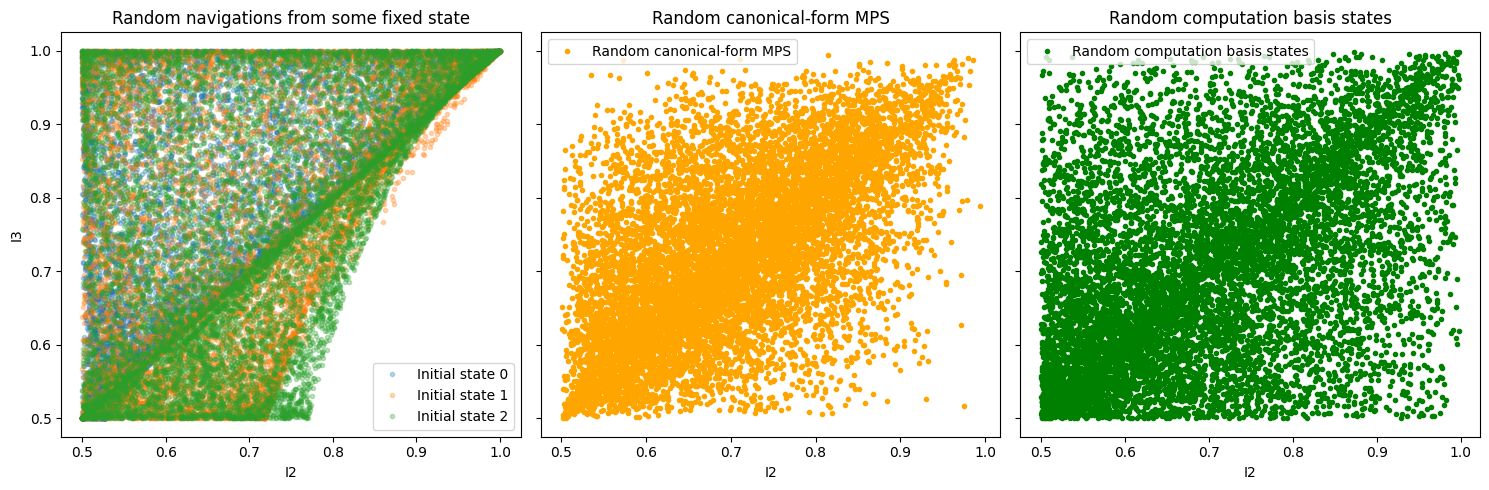

In [66]:
# Plotting the I4, I5 components

ids = [1,2]
ent_params_mulpar = [params[:, ids] for params in ent_params_all_runs]
ent_params_rand_mps_mulpar = ent_params_rand_mps[:, ids]
ent_params_rand_states_mulpar = ent_params_rand_states[:, ids]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i in range(3):
    axes[0].plot(ent_params_mulpar[i][:, 0], ent_params_mulpar[i][:, 1], '.', label='Initial state {}'.format(i), alpha=0.3)
axes[0].set_title('Random navigations from some fixed state')
axes[0].set_xlabel(f'I{ids[0]+1}')
axes[0].set_ylabel(f'I{ids[1]+1}')
axes[0].legend()

axes[1].plot(ent_params_rand_mps_mulpar[:, 0], ent_params_rand_mps_mulpar[:, 1], '.', label='Random canonical-form MPS', color='orange')
axes[1].set_title('Random canonical-form MPS')
axes[1].set_xlabel(f'I{ids[0]+1}')
axes[1].legend()

axes[2].plot(ent_params_rand_states_mulpar[:, 0], ent_params_rand_states_mulpar[:, 1], '.', label='Random computation basis states', color='green')
axes[2].set_title('Random computation basis states')
axes[2].set_xlabel(f'I{ids[0]+1}')
axes[2].legend()

plt.tight_layout()
plt.show()


## A new perturbation recipe

We try to perturb the state using two-site unitaries, to see what happens...

In [118]:
def perturb_state_with_two_site_unitaries(Psi, lr: float | None = None, site: int = 0):
    """
    Perturb the state using two-site unitaries.
    """
    if lr is None:
        U, _ = np.linalg.qr(np.random.randn(4, 4))
        U = einops.rearrange(
            U, '(a1 a2) (b1 b2) -> a1 a2 b1 b2', a1=2, a2=2, b1=2, b2=2
        )
    else:
        # Random coefficients normalized to unit sphere
        coefs = np.random.randn(9)
        coefs = coefs / np.linalg.norm(coefs)

        # Build Hamiltonian as linear combination of tensor products of Paulis
        H = np.einsum('k,kij->ij', coefs, PAULI_TENSORS_2Q)

        # Cayley transform to get unitary close to identity
        I4 = np.eye(4, dtype=np.complex128)
        U = (I4 + 1j * lr * H / 2) @ np.linalg.inv(I4 - 1j * lr * H / 2)
        U = einops.rearrange(U, '(a1 a2) (b1 b2) -> a1 a2 b1 b2', a1=2, a2=2, b1=2, b2=2)

    psi_new = einops.einsum(
        Psi[site], Psi[site+1], U,
        'd_phys_1 chi_l bond, d_phys_2 bond chi_r, d_phys_1 d_phys_2 d1 d2 -> d1 d2 chi_l chi_r'
    )
    psi_new_grouped = einops.rearrange(
        psi_new, 'd1 d2 chi_l chi_r -> (d1 chi_l) (d2 chi_r)'
    )
    Q, R = np.linalg.qr(psi_new_grouped)
    Psi[site] = einops.rearrange(Q, '(d1 chi_l) chi_r -> d1 chi_l chi_r', d1=2) # always assuming qubits
    Psi[site+1] = einops.rearrange(R, 'chi_l (d2 chi_r) -> d2 chi_l chi_r', d2=2)

    return to_canonical_form(Psi, form='B')
    
Psi = get_rand_mps(L=3, chi=3, d_phys=2, dtype=np.complex128)
Psi = to_canonical_form(Psi, form='B')
Psi_new = perturb_state_with_two_site_unitaries(Psi, site=0)

np.set_printoptions(precision=3, suppress=True)
print(f"before perturbation: {Psi}")
print(f"after perturbation: {Psi_new}")

before perturbation: [array([[[-0.191-0.298j, -0.933-0.058j]],

       [[ 0.736-0.577j,  0.012+0.354j]]]), array([[[ 0.595+0.j   ,  0.089+0.076j],
        [ 0.   +0.j   ,  0.223+0.j   ]],

       [[-0.393-0.058j,  0.031+0.119j],
        [ 0.517-0.372j, -0.042+0.041j]]]), array([[[-0.052-0.641j],
        [ 0.693+0.326j]],

       [[-0.761+0.087j],
        [-0.255+0.591j]]])]
after perturbation: [array([[[-0.073+0.417j,  0.562+0.035j]],

       [[-0.459+0.498j, -0.007-0.213j]]]), array([[[-0.809+0.j   , -0.121-0.103j],
        [-0.289+0.303j, -0.453+0.009j]],

       [[ 0.534+0.079j, -0.043-0.162j],
        [-0.639+0.446j, -0.005-0.11j ]]]), array([[[-0.052-0.641j],
        [ 0.693+0.326j]],

       [[-0.761+0.087j],
        [-0.255+0.591j]]])]


In [119]:
def scramble_state(Psi, depth: int = 10):
    for i in range(depth):
        Psi = perturb_state_with_two_site_unitaries(Psi, site=np.mod(i, 2))
    return Psi

Psi_scram = scramble_state(Psi, depth=10)
print(f"before scrambling: {Psi}")
print(f"after scrambling: {Psi_scram}")

before scrambling: [array([[[-0.347-0.154j, -0.868-0.32j ]],

       [[ 0.471-0.796j, -0.172+0.338j]]]), array([[[-0.537+0.j   , -0.066+0.065j],
        [ 0.   +0.j   , -0.236+0.j   ]],

       [[ 0.099+0.418j, -0.054+0.073j],
        [-0.364+0.559j,  0.039-0.09j ]]]), array([[[-0.052-0.641j],
        [ 0.693+0.326j]],

       [[-0.761+0.087j],
        [-0.255+0.591j]]])]
after scrambling: [array([[[-0.629+0.262j, -0.301-0.288j]],

       [[-0.191+0.193j,  0.518-0.143j]]]), array([[[-0.351+0.184j,  0.204-0.326j],
        [-0.523-0.606j, -0.238-0.069j]],

       [[ 0.572+0.433j,  0.424-0.j   ],
        [ 0.3  -0.072j, -0.438-0.108j]]]), array([[[-0.881+0.j   ],
        [ 0.229+0.415j]],

       [[-0.229+0.415j],
        [-0.881-0.j   ]]])]


In [120]:
def batch_scramble_state(Psi, batch_size: int = 100, depth: int = 10):
    """
    Batch version of scramble_state.
    
    Starting from a single MPS state, create a batch of scrambled states by applying
    random two-site unitaries alternating between bonds.
    
    Args:
        Psi: Input MPS state (list of numpy arrays)
        batch_size: Number of scrambled states to generate
        depth: Number of two-site unitary layers to apply
    
    Returns:
        Psi_batch: List of batched MPS tensors, each with shape (batch, d_phys, chi_l, chi_r)
    """
    # Convert to numpy if needed
    if isinstance(Psi[0], t.Tensor):
        Psi_np = [p.cpu().numpy() for p in Psi]
    else:
        Psi_np = Psi
    
    # Initialize with replicated state
    Psi_batch = [einops.repeat(psi, '... -> batch ...', batch=batch_size) for psi in Psi_np]
    
    # Apply scrambling: alternate between sites
    for i in range(depth):
        site = int(np.mod(i, 2))
        
        # Generate batch of random unitaries
        random_matrices = np.random.randn(batch_size, 4, 4) + 1j * np.random.randn(batch_size, 4, 4)
        U_batch = np.zeros((batch_size, 4, 4), dtype=Psi_np[0].dtype)
        for b in range(batch_size):
            U, _ = np.linalg.qr(random_matrices[b])
            U_batch[b] = U
        U_batch = einops.rearrange(
            U_batch, 'batch (a1 a2) (b1 b2) -> batch a1 a2 b1 b2', a1=2, a2=2, b1=2, b2=2
        )
        
        # Apply two-site unitary to the batch
        psi_new = einops.einsum(
            Psi_batch[site], Psi_batch[site+1], U_batch,
            'batch d_phys_1 chi_l bond, batch d_phys_2 bond chi_r, batch d_phys_1 d_phys_2 d1 d2 -> batch d1 d2 chi_l chi_r'
        )
        
        # Batched QR decomposition
        psi_new_grouped = einops.rearrange(
            psi_new, 'batch d1 d2 chi_l chi_r -> batch (d1 chi_l) (d2 chi_r)'
        )
        
        # Important: QR returns Q with shape (m, min(m,n)) not (m, n)
        m, n = psi_new_grouped.shape[1], psi_new_grouped.shape[2]
        Q = np.zeros((batch_size, m, min(m, n)), dtype=psi_new_grouped.dtype)
        R = np.zeros((batch_size, min(m, n), n), dtype=psi_new_grouped.dtype)
        for b in range(batch_size):
            Q[b], R[b] = np.linalg.qr(psi_new_grouped[b])
        
        # Update the batch
        Psi_batch[site] = einops.rearrange(Q, 'batch (d1 chi_l) chi_r -> batch d1 chi_l chi_r', d1=2)
        Psi_batch[site+1] = einops.rearrange(R, 'batch chi_l (d2 chi_r) -> batch d2 chi_l chi_r', d2=2)
    
    # Convert to canonical form (process each state individually)
    Psi_batch_canonical = []
    for i in range(batch_size):
        psi_single = [Psi_batch[j][i] for j in range(len(Psi_batch))]
        psi_canonical = to_canonical_form(psi_single, form='B')
        if i == 0:
            # Initialize the batch structure
            Psi_batch_canonical = [np.zeros((batch_size,) + p.shape, dtype=p.dtype) for p in psi_canonical]
        for j in range(len(psi_canonical)):
            Psi_batch_canonical[j][i] = psi_canonical[j]
    
    return Psi_batch_canonical

In [154]:
def batch_perturb_with_two_site_unitaries(Psi, batch_size: int = 100, lr: float | None = None, site: int = 0):
    """
    Batch version of perturb_state_with_two_site_unitaries.
    
    Starting from a single MPS state, create a batch of perturbed states using random two-site unitaries.
    
    Args:
        Psi: Input MPS state (list of numpy arrays)
        batch_size: Number of perturbed states to generate
        lr: Learning rate for small perturbations (if None, uses random unitaries)
        site: Which bond to apply the two-site unitary (0 or 1 for 3-site system)
    
    Returns:
        Psi_batch: List of batched MPS tensors, each with shape (batch, d_phys, chi_l, chi_r)
    """
    # Convert to numpy if needed
    if isinstance(Psi[0], t.Tensor):
        Psi_np = [p.cpu().numpy() for p in Psi]
    else:
        Psi_np = Psi
    
    # Replicate state to create batch
    Psi_batch = [einops.repeat(psi, '... -> batch ...', batch=batch_size) for psi in Psi_np]
    
    # Generate batch of random 4x4 unitary matrices
    if lr is None:
        # Generate batch of random unitaries via QR decomposition
        random_matrices = np.random.randn(batch_size, 4, 4) + 1j * np.random.randn(batch_size, 4, 4)
        U_batch = np.zeros((batch_size, 4, 4), dtype=Psi_np[0].dtype)
        for i in range(batch_size):
            U, _ = np.linalg.qr(random_matrices[i])
            U_batch[i] = U
        # Rearrange to two-site form: (batch, a1, a2, b1, b2)
        U_batch = einops.rearrange(
            U_batch, 'batch (a1 a2) (b1 b2) -> batch a1 a2 b1 b2', a1=2, a2=2, b1=2, b2=2
        )
    else:
        # Small perturbations around identity using vectorized Cayley transform
        I4 = np.eye(4, dtype=np.complex128)
        
        # Generate batched random coefficients (normalized to unit sphere)
        coefs_batch = np.random.randn(batch_size, 9)
        coefs_batch = coefs_batch / np.linalg.norm(coefs_batch, axis=1, keepdims=True)
        
        # Build batched Hamiltonians using vectorized einsum
        # H[b] = sum_k coefs[b,k] * PAULI_TENSORS_2Q[k]
        H_batch = np.einsum('bk,kij->bij', coefs_batch, PAULI_TENSORS_2Q)
        
        # Vectorized Cayley transform: U = (I + i*lr*H/2) @ inv(I - i*lr*H/2)
        numerator = I4[None, :, :] + 1j * lr * H_batch / 2      # Broadcasting I4 over batch
        denominator = I4[None, :, :] - 1j * lr * H_batch / 2
        
        # Batched matrix inversion and multiplication
        U_batch = numerator @ np.linalg.inv(denominator)  # Shape: (batch_size, 4, 4)

        # Rearrange to two-site form: (batch, a1, a2, b1, b2)
        U_batch = einops.rearrange(
            U_batch, 'batch (a1 a2) (b1 b2) -> batch a1 a2 b1 b2', a1=2, a2=2, b1=2, b2=2
        )
    
    # Apply two-site unitary to the specified bond
    psi_new = einops.einsum(
        Psi_batch[site], Psi_batch[site+1], U_batch,
        'batch d_phys_1 chi_l bond, batch d_phys_2 bond chi_r, batch d_phys_1 d_phys_2 d1 d2 -> batch d1 d2 chi_l chi_r'
    )
    
    # Group indices for QR decomposition
    psi_new_grouped = einops.rearrange(
        psi_new, 'batch d1 d2 chi_l chi_r -> batch (d1 chi_l) (d2 chi_r)'
    )
    
    # Batched QR decomposition
    # Important: QR returns Q with shape (m, min(m,n)) not (m, n)
    m, n = psi_new_grouped.shape[1], psi_new_grouped.shape[2]
    Q = np.zeros((batch_size, m, min(m, n)), dtype=psi_new_grouped.dtype)
    R = np.zeros((batch_size, min(m, n), n), dtype=psi_new_grouped.dtype)
    for i in range(batch_size):
        Q[i], R[i] = np.linalg.qr(psi_new_grouped[i])
    
    # Update the batch
    Psi_batch[site] = einops.rearrange(Q, 'batch (d1 chi_l) chi_r -> batch d1 chi_l chi_r', d1=2)
    Psi_batch[site+1] = einops.rearrange(R, 'batch chi_l (d2 chi_r) -> batch d2 chi_l chi_r', d2=2)
    
    # Convert each state in batch to canonical form
    Psi_batch_canonical = []
    for i in range(batch_size):
        psi_single = [Psi_batch[j][i] for j in range(len(Psi_batch))]
        psi_canonical = to_canonical_form(psi_single, form='B')
        if i == 0:
            # Initialize the batch structure
            Psi_batch_canonical = [np.zeros((batch_size,) + p.shape, dtype=p.dtype) for p in psi_canonical]
        for j in range(len(psi_canonical)):
            Psi_batch_canonical[j][i] = psi_canonical[j]
    
    if lr is None:
        return Psi_batch_canonical
    else:
        return Psi_batch, coefs_batch


In [155]:
# Test the batch functions
print("Testing batch_perturb_with_two_site_unitaries...")
Psi_test = get_rand_mps(L=3, chi=3, d_phys=2, dtype=np.complex128)
Psi_test = to_canonical_form(Psi_test, form='B')

# Test batch perturb
Psi_batch_perturb, coefs_batch = batch_perturb_with_two_site_unitaries(Psi_test, batch_size=5, site=0, lr=0.01)
print(f"Input shape: {[p.shape for p in Psi_test]}")
print(f"Batch perturb output shape: {[p.shape for p in Psi_batch_perturb]}")
print(f"Coefs batch shape: {coefs_batch.shape}")

# Test batch scramble
print("\nTesting batch_scramble_state...")
Psi_batch_scramble = batch_scramble_state(Psi_test, batch_size=5, depth=10)
print(f"Batch scramble output shape: {[p.shape for p in Psi_batch_scramble]}")

# Verify states are different
print("\nVerifying batch contains different states...")
# state_0 = to_comp_basis([Psi_batch_scramble[i][0] for i in range(len(Psi_batch_scramble))])
# state_1 = to_comp_basis([Psi_batch_scramble[i][1] for i in range(len(Psi_batch_scramble))])
state_0 = to_comp_basis([Psi_batch_perturb[i][0] for i in range(len(Psi_batch_perturb))])
state_1 = to_comp_basis([Psi_batch_perturb[i][1] for i in range(len(Psi_batch_perturb))])
print(f"State 0: {state_0}")
print(f"State 1: {state_1}")
print(f"States are different: {not np.allclose(state_0, state_1)}")

Testing batch_perturb_with_two_site_unitaries...
Input shape: [(2, 1, 2), (2, 2, 2), (2, 2, 1)]
Batch perturb output shape: [(5, 2, 1, 2), (5, 2, 2, 2), (5, 2, 2, 1)]
Coefs batch shape: (5, 9)

Testing batch_scramble_state...
Batch scramble output shape: [(5, 2, 1, 2), (5, 2, 2, 2), (5, 2, 2, 1)]

Verifying batch contains different states...
State 0: [ 0.103-0.089j  0.062-0.373j  0.372-0.216j  0.398-0.242j  0.029-0.206j
 -0.402-0.359j -0.226+0.1j   -0.207+0.j   ]
State 1: [ 0.102-0.09j   0.056-0.375j  0.374-0.216j  0.399-0.241j  0.028-0.205j
 -0.403-0.357j -0.222+0.1j   -0.205+0.001j]
States are different: True


Generating and analyzing batch-scrambled MPS states...

Initializing random MPS state 1/3...
  State 1 in comp basis: [-0.169+0.389j  0.245+0.408j  0.319+0.5j   -0.368+0.144j]...
Initializing random MPS state 2/3...
  State 2 in comp basis: [ 0.071+0.061j -0.052-0.244j -0.062+0.18j   0.021-0.338j]...
Initializing random MPS state 3/3...
  State 3 in comp basis: [ 0.065-0.276j  0.125+0.135j -0.269+0.221j -0.201-0.15j ]...

Batch scrambling with batch_size=10000, depth=10...
  Scrambling initial state 1/3...


  Converting to comp basis (state 1): 100%|██████████| 10000/10000 [00:00<00:00, 222376.19it/s]


  Scrambling initial state 2/3...


  Converting to comp basis (state 2): 100%|██████████| 10000/10000 [00:00<00:00, 235949.21it/s]


  Scrambling initial state 3/3...


...

  State 1 ent params shape: (10000, 5)


  Computing ent params (state 2): 100%|██████████| 10000/10000 [00:01<00:00, 7229.02it/s]


  State 2 ent params shape: (10000, 5)


  Computing ent params (state 3): 100%|██████████| 10000/10000 [00:01<00:00, 7171.23it/s]


  State 3 ent params shape: (10000, 5)

Generating I4-I5 comparison plot...


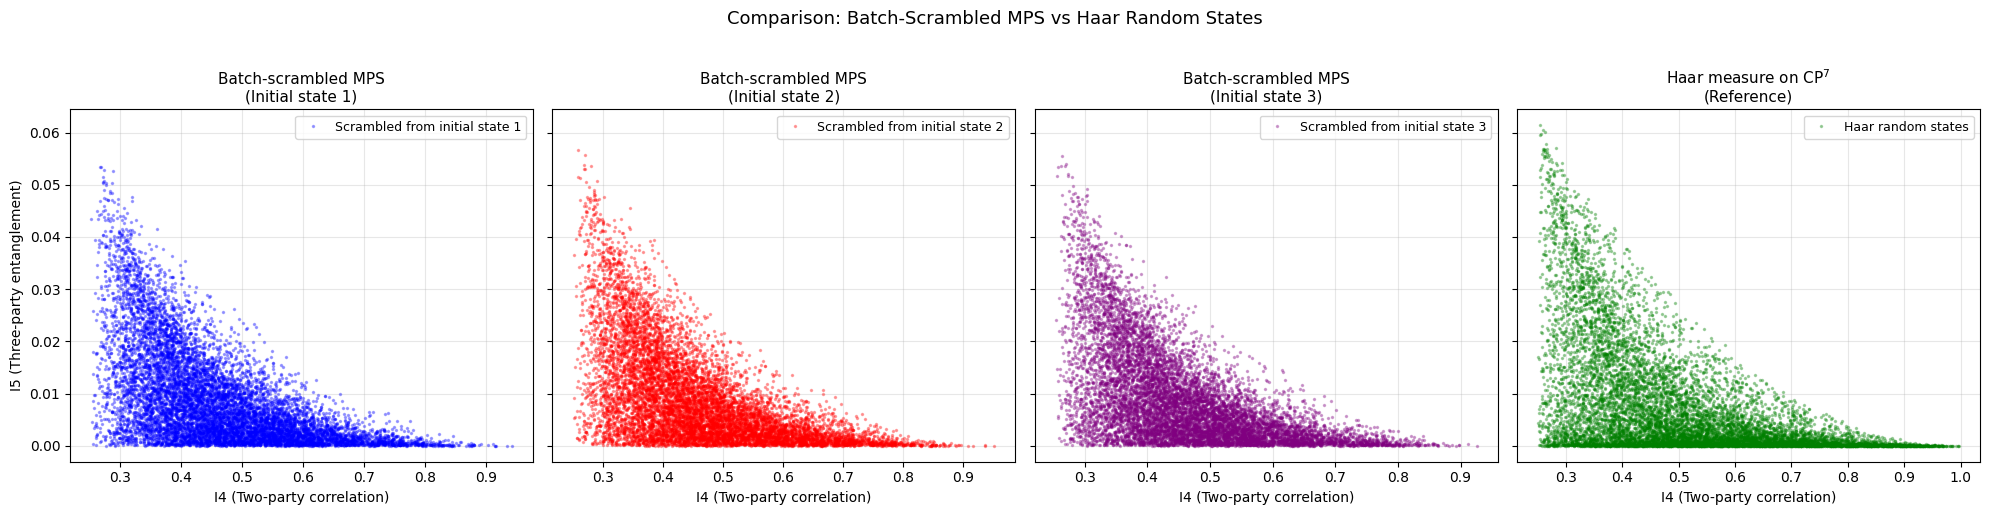


Summary:
  Batch-scrambled states: 3 × 10000 = 30000 total
  Haar random states: 10000
  Scrambling depth: 10 layers
  I4 range (scrambled): [0.251, 0.952]
  I4 range (Haar): [0.251, 0.997]
  I5 range (scrambled): [0.000, 0.057]
  I5 range (Haar): [0.000, 0.061]


In [ ]:
# Compare batch-scrambled MPS states with Haar random states
print("Generating and analyzing batch-scrambled MPS states...\n")

# 1. Initialize multiple random MPS states
num_initial_states = 3
batch_size = 10000
depth = 10

initial_states = []
for i in range(num_initial_states):
    print(f"Initializing random MPS state {i+1}/{num_initial_states}...")
    Psi = get_rand_mps(L=3, chi=3, d_phys=2, dtype=np.complex128)
    Psi = to_canonical_form(Psi, form='B')
    initial_states.append(Psi)
    print(f"  State {i+1} in comp basis: {to_comp_basis(Psi)[:4]}...")  # Show first 4 components

# 2. Batch scramble each initial state
print(f"\nBatch scrambling with batch_size={batch_size}, depth={depth}...")
all_scrambled_comp_basis = []

for idx, psi in enumerate(initial_states):
    print(f"  Scrambling initial state {idx+1}/{num_initial_states}...")
    Psi_batch = batch_scramble_state(psi, batch_size=batch_size, depth=depth)
    
    # 3. Convert batch to computation basis
    comp_basis_states = []
    for i in tqdm(range(batch_size), desc=f"  Converting to comp basis (state {idx+1})"):
        psi_single = [Psi_batch[j][i] for j in range(len(Psi_batch))]
        comp_basis_states.append(to_comp_basis(psi_single))
    all_scrambled_comp_basis.append(comp_basis_states)

# 4. Compute entanglement parameters
print("\nComputing entanglement parameters...")
scrambled_ent_params = []

for idx, run_states in enumerate(all_scrambled_comp_basis):
    ent_params = []
    for state in tqdm(run_states, desc=f"  Computing ent params (state {idx+1})"):
        ent_params.append(compute_ent_params_from_state(state))
    ent_params = np.real(np.stack(ent_params))
    scrambled_ent_params.append(ent_params)
    print(f"  State {idx+1} ent params shape: {ent_params.shape}")





Generating I4-I5 comparison plot...


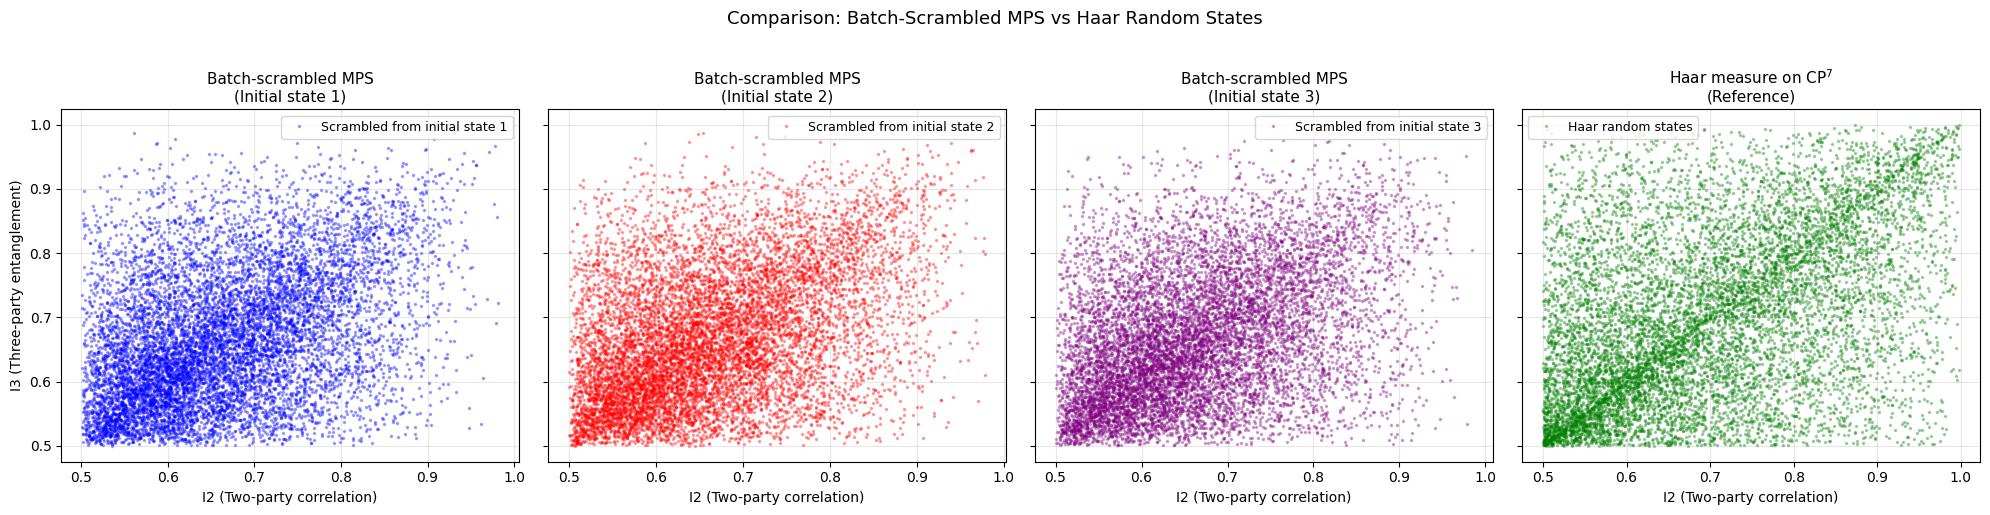


Summary:
  Batch-scrambled states: 3 × 10000 = 30000 total
  Haar random states: 10000
  Scrambling depth: 10 layers
  I4 range (scrambled): [0.500, 0.985]
  I4 range (Haar): [0.500, 0.998]
  I5 range (scrambled): [0.500, 0.987]
  I5 range (Haar): [0.500, 0.999]


In [92]:
# 5. Plot I4-I5 slice comparison
print("\nGenerating I4-I5 comparison plot...")
ids = [1, 2]  # I4 and I5 (0-indexed)
scrambled_mulpar = [params[:, ids] for params in scrambled_ent_params]
ent_params_rand_states_mulpar = ent_params_rand_states[:, ids]
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

# Plots for each scrambled state type
colors = ['blue', 'red', 'purple']
for i in range(num_initial_states):
    axes[i].plot(scrambled_mulpar[i][:, 0], scrambled_mulpar[i][:, 1], 
                 '.', label=f'Scrambled from initial state {i+1}', 
                 color=colors[i], alpha=0.3, markersize=3)
    axes[i].set_title(f'Batch-scrambled MPS\n(Initial state {i+1})', fontsize=11)
    axes[i].set_xlabel(f'I{ids[0]+1} (Two-party correlation)', fontsize=10)
    if i == 0:
        axes[i].set_ylabel(f'I{ids[1]+1} (Three-party entanglement)', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

# Haar measure reference
axes[3].plot(ent_params_rand_states_mulpar[:, 0], ent_params_rand_states_mulpar[:, 1], 
             '.', label='Haar random states', color='green', alpha=0.3, markersize=3)
axes[3].set_title('Haar measure on CP$^7$\n(Reference)', fontsize=11)
axes[3].set_xlabel(f'I{ids[0]+1} (Two-party correlation)', fontsize=10)
axes[3].legend(fontsize=9)
axes[3].grid(True, alpha=0.3)

plt.suptitle('Comparison: Batch-Scrambled MPS vs Haar Random States', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Batch-scrambled states: {num_initial_states} × {batch_size} = {num_initial_states * batch_size} total")
print(f"  Haar random states: {len(ent_params_rand_states)}")
print(f"  Scrambling depth: {depth} layers")
print(f"  I4 range (scrambled): [{np.min([s[:, 0].min() for s in scrambled_mulpar]):.3f}, {np.max([s[:, 0].max() for s in scrambled_mulpar]):.3f}]")
print(f"  I4 range (Haar): [{ent_params_rand_states_mulpar[:, 0].min():.3f}, {ent_params_rand_states_mulpar[:, 0].max():.3f}]")
print(f"  I5 range (scrambled): [{np.min([s[:, 1].min() for s in scrambled_mulpar]):.3f}, {np.max([s[:, 1].max() for s in scrambled_mulpar]):.3f}]")
print(f"  I5 range (Haar): [{ent_params_rand_states_mulpar[:, 1].min():.3f}, {ent_params_rand_states_mulpar[:, 1].max():.3f}]")

## Random Unitaries

In [ ]:
# Define Pauli matrices once at module level
PAULIS = [
    np.array([[0, 1], [1, 0]], dtype=np.complex128),      # σ_x
    np.array([[0, -1j], [1j, 0]], dtype=np.complex128),   # σ_y
    np.array([[1, 0], [0, -1]], dtype=np.complex128)      # σ_z
]

# Pre-compute all 9 two-qubit Pauli operators (σᵢ ⊗ σⱼ)
# This is used for efficient vectorized Cayley transform
PAULI_TENSORS_2Q = np.array([
    np.kron(PAULIS[i], PAULIS[j]) 
    for i in range(3) for j in range(3)
])  # Shape: (9, 4, 4)

def get_rand_2q_unitary(lr: float = 0.01):
    """
    Get a random 2-qubit unitary using Cayley transform.
    
    Generates unitary close to identity with HS distance ~ lr^2 for small lr.
    """
    # Random coefficients normalized to unit sphere
    coefs = np.random.randn(9)
    coefs = coefs / np.linalg.norm(coefs)

    # Build Hamiltonian as linear combination of Pauli tensor products
    H = np.einsum('k,kij->ij', coefs, PAULI_TENSORS_2Q)
    
    # Cayley transform: U = (I + i*lr*H/2) @ inv(I - i*lr*H/2)
    I4 = np.eye(4, dtype=np.complex128)
    U = (I4 + 1j * lr * H / 2) @ np.linalg.inv(I4 - 1j * lr * H / 2)
    return U

def hs_distance(A, B):
    if A.dtype == np.complex128 or B.dtype == np.complex128:
        return np.trace((A-B) @ (A-B).conj().T).real
    else:
        return np.trace((A-B) @ (A-B).T).real


U = get_rand_2q_unitary()
print(hs_distance(U, np.eye(4, dtype=np.complex128)))

print(np.linalg.norm(U @ U.conj().T - np.eye(4, dtype=np.complex128)))

### Test

<>:42: SyntaxWarning:

invalid escape sequence '\p'

<>:42: SyntaxWarning:

invalid escape sequence '\p'

/var/folders/1s/zs9ynm1d30v6x5mppn67y8h00000gp/T/ipykernel_92111/2281694853.py:42: SyntaxWarning:

invalid escape sequence '\p'



Testing get_rand_2q_unitary with varying learning rates...



Computing HS distances: 100%|██████████| 50/50 [00:00<00:00, 105.82it/s]


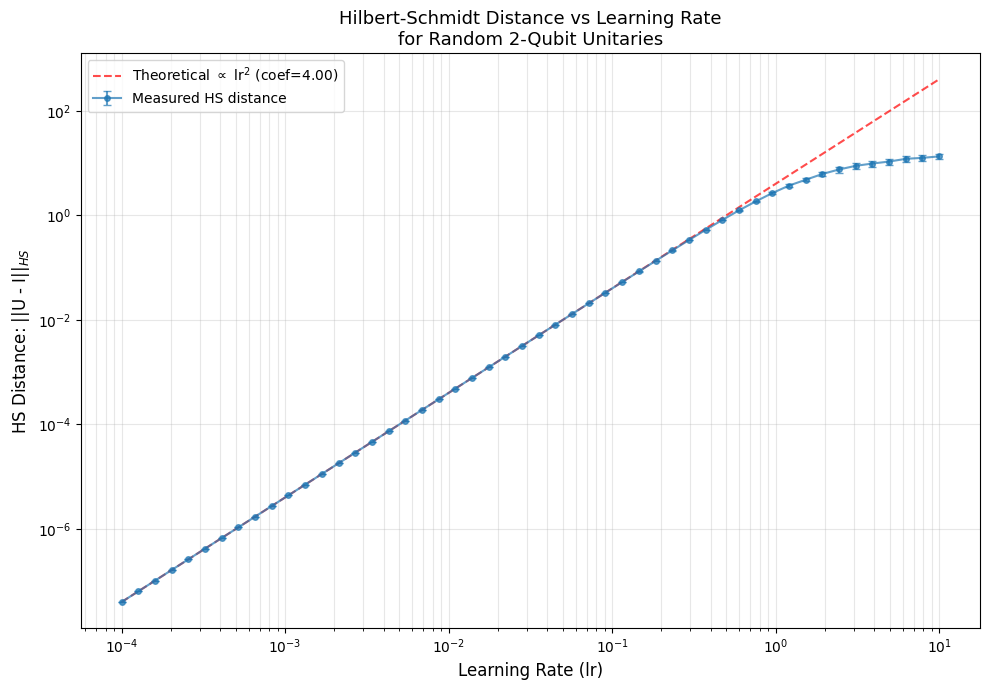


Summary:
  Learning rate range: [1.0e-04, 1.0e+01]
  HS distance range: [4.000e-08, 1.338e+01]
  Samples per lr: 100

Small lr regime (lr < 0.1):
  Mean HS/lr^2 ratio: 3.9987 ± 0.0031

Large lr regime (lr > 1):
  Mean HS distance: 8.9350 ± 3.1679
  (Shows saturation behavior)


In [115]:
# Test get_rand_2q_unitary: HS distance vs learning rate
print("Testing get_rand_2q_unitary with varying learning rates...\n")

# Generate learning rates in log space
lr_values = np.logspace(-4, 1, 50)  # From 1e-4 to 10
num_samples = 100  # Number of random unitaries per lr value

# Compute HS distances
hs_distances_mean = []
hs_distances_std = []

I4 = np.eye(4, dtype=np.complex128)

for lr in tqdm(lr_values, desc="Computing HS distances"):
    distances = []
    for _ in range(num_samples):
        U = get_rand_2q_unitary(lr=lr)
        dist = hs_distance(U, I4)
        distances.append(dist)
    
    hs_distances_mean.append(np.mean(distances))
    hs_distances_std.append(np.std(distances))

hs_distances_mean = np.array(hs_distances_mean)
hs_distances_std = np.array(hs_distances_std)

# Plot in log-log scale
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Main plot with error bars
ax.errorbar(lr_values, hs_distances_mean, yerr=hs_distances_std, 
            fmt='o-', label='Measured HS distance', 
            capsize=3, markersize=4, alpha=0.7)

# Theoretical lr^2 scaling for small lr
small_lr_regime = lr_values < 0.1
if np.any(small_lr_regime):
    # Fit coefficient in small lr regime
    fit_coef = np.mean(hs_distances_mean[small_lr_regime] / lr_values[small_lr_regime]**2)
    theoretical_line = fit_coef * lr_values**2
    ax.plot(lr_values, theoretical_line, '--', 
            label=f'Theoretical $\propto$ lr$^2$ (coef={fit_coef:.2f})', 
            color='red', alpha=0.7)

ax.set_xlabel('Learning Rate (lr)', fontsize=12)
ax.set_ylabel('HS Distance: ||U - I||$_{HS}$', fontsize=12)
ax.set_title('Hilbert-Schmidt Distance vs Learning Rate\nfor Random 2-Qubit Unitaries', fontsize=13)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Learning rate range: [{lr_values.min():.1e}, {lr_values.max():.1e}]")
print(f"  HS distance range: [{hs_distances_mean.min():.3e}, {hs_distances_mean.max():.3e}]")
print(f"  Samples per lr: {num_samples}")
print(f"\nSmall lr regime (lr < 0.1):")
print(f"  Mean HS/lr^2 ratio: {fit_coef:.4f} ± {np.std(hs_distances_mean[small_lr_regime] / lr_values[small_lr_regime]**2):.4f}")
print(f"\nLarge lr regime (lr > 1):")
large_lr_regime = lr_values > 1
if np.any(large_lr_regime):
    print(f"  Mean HS distance: {hs_distances_mean[large_lr_regime].mean():.4f} ± {hs_distances_mean[large_lr_regime].std():.4f}")
    print(f"  (Shows saturation behavior)")

## Initial equilibrium finding

Given a two-qubit state, compute the Nash equilibrium

In [5]:
Psi = get_rand_mps(L=2, chi=3, d_phys=2, dtype=np.complex128)
for i in range(len(Psi)):
    print(f"Site {i} has shape {Psi[i].shape}")

# Gathers statistics of the state

Site 0 has shape (2, 1, 2)
Site 1 has shape (2, 2, 1)


In [28]:
psi = to_comp_basis(Psi)
Psi_ = to_canonical_form(Psi, form='B')
print(f"Left canonical form: {Psi}")
print(f"Right canonical form: {Psi_}")
psi_ = to_comp_basis(Psi_)

Left canonical form: [array([[[-0.606-0.12j , -0.518+0.592j]],

       [[-0.333+0.713j, -0.354-0.506j]]]), array([[[-0.821-0.08j ],
        [ 0.158+0.082j]],

       [[ 0.444-0.196j],
        [ 0.225+0.04j ]]])]
Right canonical form: [array([[[-0.56 -0.146j,  0.148-0.169j]],

       [[-0.299+0.703j,  0.101+0.144j]]]), array([[[-0.858-0.083j],
        [-0.412-0.296j]],

       [[ 0.464-0.205j],
        [-0.856-0.096j]]])]


In [34]:
# NOTE: batch perturb must start from B canonical form
Psi_batch, original_S, batch_perturbed_S = batch_perturb(Psi_, batch_size=1, lr=0.03, site=0)
# print(Psi_batch)
print(original_S)
print(batch_perturbed_S)
# U, S, Vh = np.linalg.svd(
#     einops.rearrange(
#         Psi[0], 
#         'd_phys chi_l chi_r -> (d_phys chi_l) chi_r'
# )
Psi_test = [psi[0] for psi in Psi_batch]
test_canonical_form(Psi_test, form='A')
Psi_test_ = to_canonical_form(Psi_test, form='A')

assert all(np.allclose(psi, psi_) for psi, psi_ in zip(Psi_test, Psi_test_))


[[0.959 0.285]]
[[0.957 0.291]]


In [38]:
def get_schmidt_eigval(Psi):
    Psi_ = to_canonical_form(Psi, form='B')
    U, S, Vh = np.linalg.svd(
        einops.rearrange(
            Psi_[0], 
            'd_phys chi_l chi_r -> (d_phys chi_l) chi_r'
        ),
        full_matrices=False,
    )
    return S[0] # The larger Schmidt value

get_schmidt_eigval(Psi)
    

0.9585012601927729